# Identificação de Ativos IoT em Redes Corporativas utilizando Redes Neurais Artificiais — Versão 02

**Disciplina:** Redes Neurais em Segurança Cibernética  
**PPEE – Universidade de Brasília (UnB)**  
**Tema:** Controle 1 – Inventário e Controle de Ativos Corporativos

## Objetivo
Desenvolver e avaliar uma Rede Neural Artificial para classificação de dispositivos IoT a partir de características de tráfego de rede.

### Melhorias em relação à Versão 01
- avaliação com o conjunto oficial de teste;
- validação interna estratificada;
- remoção de features constantes;
- análise de possíveis identificadores;
- prevenção de data leakage no pré-processamento;
- baseline para comparação;
- Accuracy, Balanced Accuracy e F1;
- matriz de confusão e métricas por classe;
- análise de confiança e erros;
- simulação de apoio ao inventário de ativos.

In [1]:
# 1. INSTALAÇÃO
!pip -q install pandas numpy matplotlib seaborn scikit-learn tensorflow joblib

In [2]:
# 2. IMPORTAÇÃO E REPRODUTIBILIDADE
import os, glob, zipfile, warnings, random, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, f1_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", __import__("sklearn").__version__)
print("Seed:", SEED)

TensorFlow: 2.20.0
Pandas: 2.2.3
Scikit-learn: 1.6.1
Seed: 42


## 3. Download e carregamento

O notebook utiliza o dataset **IoT Device Identification** do Kaggle. Os arquivos de treinamento e teste serão mantidos separados.

In [3]:
# 3. DOWNLOAD E DESCOMPACTAÇÃO
DATASET_DIR = "/content/iot_dataset"
ZIP_PATH = "/content/iot-device-identification.zip"

os.makedirs(DATASET_DIR, exist_ok=True)

!wget -q -O /content/iot-device-identification.zip \
"https://www.kaggle.com/api/v1/datasets/download/fanbyprinciple/iot-device-identification"

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(DATASET_DIR)

print("Arquivos:")
for root, dirs, files in os.walk(DATASET_DIR):
    for f in files:
        print(os.path.join(root, f))

Arquivos:
/content/iot_dataset/iot_device_train.csv
/content/iot_dataset/iot_device_test.csv


In [4]:
# 4. LEITURA
TRAIN_FILE = os.path.join(DATASET_DIR, "iot_device_train.csv")
TEST_FILE = os.path.join(DATASET_DIR, "iot_device_test.csv")

df_train = pd.read_csv(TRAIN_FILE)
df_test = pd.read_csv(TEST_FILE)

TARGET = "device_category"

print("Treinamento:", df_train.shape)
print("Teste oficial:", df_test.shape)
print("\nClasses de treinamento:")
print(sorted(df_train[TARGET].unique()))
print("\nClasses de teste:")
print(sorted(df_test[TARGET].unique()))

Treinamento: (1000, 298)
Teste oficial: (900, 298)

Classes de treinamento:
['TV', 'baby_monitor', 'lights', 'motion_sensor', 'security_camera', 'smoke_detector', 'socket', 'thermostat', 'watch', 'water_sensor']

Classes de teste:
['TV', 'baby_monitor', 'lights', 'motion_sensor', 'security_camera', 'smoke_detector', 'socket', 'thermostat', 'watch']


,Treinamento,Teste
device_category,,
TV,100,100
baby_monitor,100,100
lights,100,100
motion_sensor,100,100
security_camera,100,100
smoke_detector,100,100
socket,100,100
thermostat,100,100
watch,100,100


<Figure size 1200x600 with 0 Axes>

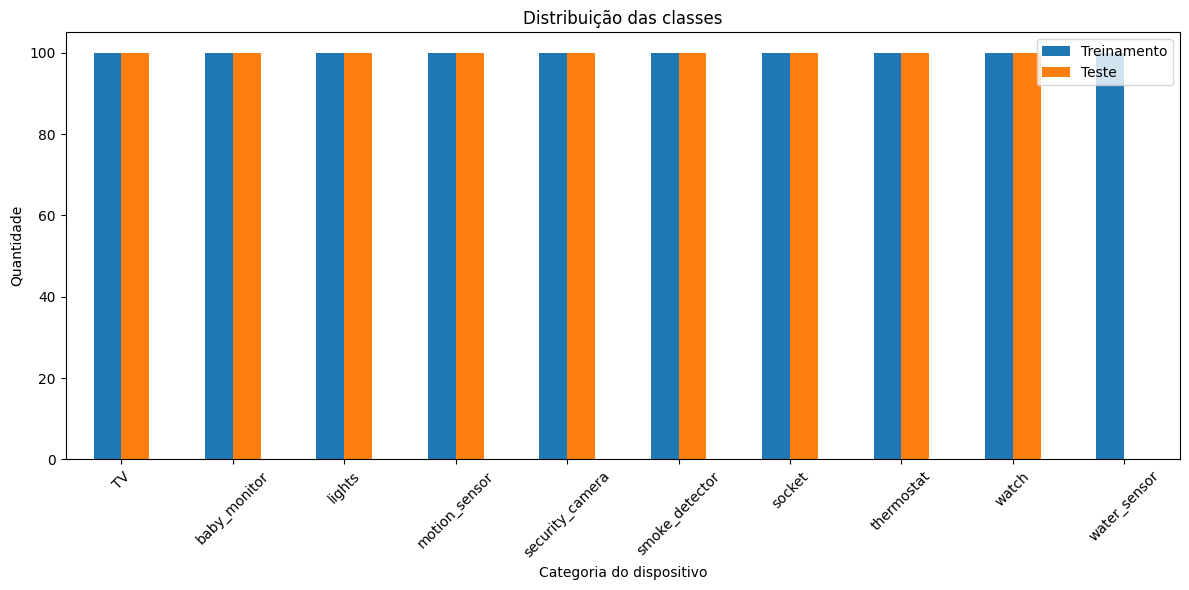

In [5]:
# 5. DISTRIBUIÇÃO DAS CLASSES
distribution = pd.concat([
    df_train[TARGET].value_counts().rename("Treinamento"),
    df_test[TARGET].value_counts().rename("Teste")
], axis=1).fillna(0).astype(int).sort_index()

display(distribution)

plt.figure(figsize=(12, 6))
distribution.plot(kind="bar", figsize=(12, 6))
plt.title("Distribuição das classes")
plt.xlabel("Categoria do dispositivo")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Observação sobre o teste oficial

O treinamento possui 10 categorias, enquanto o teste oficial possui 9. `water_sensor` está presente no treinamento, mas não no teste oficial.

Assim, o desempenho de `water_sensor` será analisado na validação interna, mas não pode ser medido no teste oficial.

In [6]:
# 7. INSPEÇÃO
print("Valores ausentes - treinamento:", df_train.isna().sum().sum())
print("Valores ausentes - teste:", df_test.isna().sum().sum())

print("\nTipos:")
display(df_train.dtypes.value_counts())

X_full = df_train.drop(columns=[TARGET]).copy()
y_full = df_train[TARGET].copy()

X_test_official = df_test.drop(columns=[TARGET]).copy()
y_test_official = df_test[TARGET].copy()

Valores ausentes - treinamento: 0
Valores ausentes - teste: 0

Tipos:


,count
int64,217
float64,80
object,1


In [7]:
# 8. CARDINALIDADE
cardinality = pd.DataFrame({
    "feature": X_full.columns,
    "unique_values": [X_full[c].nunique(dropna=False) for c in X_full.columns],
    "unique_ratio": [X_full[c].nunique(dropna=False)/len(X_full) for c in X_full.columns]
}).sort_values("unique_ratio", ascending=False)

display(cardinality.head(30))

,feature,unique_values,unique_ratio
113,packet_inter_arrivel_sum,978,0.978
106,packet_inter_arrivel_avg,978,0.978
112,packet_inter_arrivel_stdev,975,0.975
115,packet_inter_arrivel_var,975,0.975
109,packet_inter_arrivel_max,973,0.973
93,packet_inter_arrivel_A_sum,973,0.973
86,packet_inter_arrivel_A_avg,973,0.973
92,packet_inter_arrivel_A_stdev,970,0.970
95,packet_inter_arrivel_A_var,970,0.970
89,packet_inter_arrivel_A_max,969,0.969


In [8]:
# 9. FEATURES CONSTANTES
constant_features = [c for c in X_full.columns if X_full[c].nunique(dropna=False) <= 1]

print("Features constantes:", len(constant_features))
if constant_features:
    print(constant_features)

X_full = X_full.drop(columns=constant_features)
X_test_official = X_test_official.drop(columns=constant_features)

print("Dimensão final do treinamento:", X_full.shape)
print("Dimensão final do teste:", X_test_official.shape)

Features constantes: 137
['ds_field_A', 'http_POST', 'http_bytes_entropy', 'http_bytes_stdev', 'http_bytes_var', 'http_cookie_values_avg', 'http_cookie_values_entropy', 'http_cookie_values_firstQ', 'http_cookie_values_max', 'http_cookie_values_median', 'http_cookie_values_min', 'http_cookie_values_stdev', 'http_cookie_values_sum', 'http_cookie_values_thirdQ', 'http_cookie_values_var', 'http_has_referrer', 'http_inter_arrivel_entropy', 'http_inter_arrivel_stdev', 'http_inter_arrivel_var', 'http_req_bytes_entropy', 'http_req_bytes_stdev', 'http_req_bytes_var', 'http_resp_bytes_entropy', 'http_resp_bytes_stdev', 'http_resp_bytes_var', 'http_time_entropy', 'http_time_stdev', 'http_time_var', 'packet_size_A_firstQ', 'packet_size_A_median', 'packet_size_A_min', 'packet_size_B_firstQ', 'packet_size_B_median', 'packet_size_B_min', 'packet_size_firstQ', 'packet_size_median', 'packet_size_min', 'ssl_count_certificates', 'ssl_count_client_cipher_algs', 'ssl_count_client_ciphersuites', 'ssl_count_

## 10. Divisão treino/validação

O conjunto de treinamento do Kaggle será dividido em 80% para treinamento e 20% para validação, com estratificação. O teste oficial permanece intocado até a avaliação final.

In [9]:
# 10. TRAIN / VALIDATION SPLIT
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full,
    test_size=0.20,
    random_state=SEED,
    stratify=y_full
)

print("Treino:", X_train.shape)
print("Validação:", X_val.shape)

Treino: (800, 160)
Validação: (200, 160)


In [10]:
# 11. CODIFICAÇÃO DO TARGET
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)

class_names = label_encoder.classes_
NUM_CLASSES = len(class_names)

for i, name in enumerate(class_names):
    print(i, "->", name)

0 -> TV
1 -> baby_monitor
2 -> lights
3 -> motion_sensor
4 -> security_camera
5 -> smoke_detector
6 -> socket
7 -> thermostat
8 -> watch
9 -> water_sensor


In [11]:
# 12. PRÉ-PROCESSAMENTO SEM DATA LEAKAGE
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_official_scaled = preprocessor.transform(X_test_official)

print("Treino:", X_train_scaled.shape)
print("Validação:", X_val_scaled.shape)
print("Teste:", X_test_official_scaled.shape)
print("NaN:", np.isnan(X_train_scaled).sum())
print("Inf:", np.isinf(X_train_scaled).sum())

Treino: (800, 160)
Validação: (200, 160)
Teste: (900, 160)
NaN: 0
Inf: 0


In [12]:
# 13. BASELINE
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train_scaled, y_train_enc)
baseline_pred = baseline.predict(X_val_scaled)

print("Baseline Accuracy:",
      f"{accuracy_score(y_val_enc, baseline_pred):.4f}")
print("Baseline Macro-F1:",
      f"{f1_score(y_val_enc, baseline_pred, average='macro', zero_division=0):.4f}")

Baseline Accuracy: 0.1000
Baseline Macro-F1: 0.0182


## 14. Rede Neural Artificial

Arquitetura: **Entrada → Dense(128) → Dropout → Dense(64) → Dropout → Dense(32) → Softmax**.

In [13]:
# 14. CONSTRUÇÃO DO MODELO
input_dim = X_train_scaled.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(32, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,274 (122.16 KB)

 Trainable params: 31,274 (122.16 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# 15. TREINAMENTO
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train_enc,
    validation_data=(X_val_scaled, y_val_enc),
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("Melhor época:", np.argmin(history.history["val_loss"]) + 1)

Epoch 1/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.2988 - loss: 2.0428 - val_accuracy: 0.5850 - val_loss: 1.5036
Epoch 2/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5263 - loss: 1.4544 - val_accuracy: 0.7000 - val_loss: 0.9980
Epoch 3/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6288 - loss: 1.0207 - val_accuracy: 0.7350 - val_loss: 0.7317
Epoch 4/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6888 - loss: 0.8404 - val_accuracy: 0.7800 - val_loss: 0.6098
Epoch 5/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7163 - loss: 0.7030 - val_accuracy: 0.7800 - val_loss: 0.5352
Epoch 6/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7412 - loss: 0.6400 - val_accuracy: 0.8050 - val_loss: 0.5173
Epoch 7/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7550 - loss: 0.5804 - val_accuracy: 0.7950 - val_loss: 0.4781
Epoch 8/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7738 - loss: 0.5420 - val_accuracy: 0.

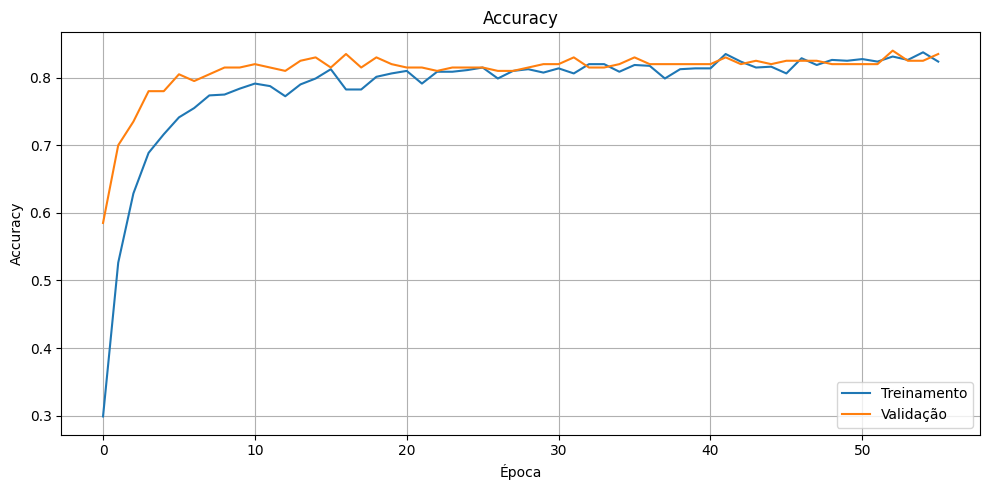

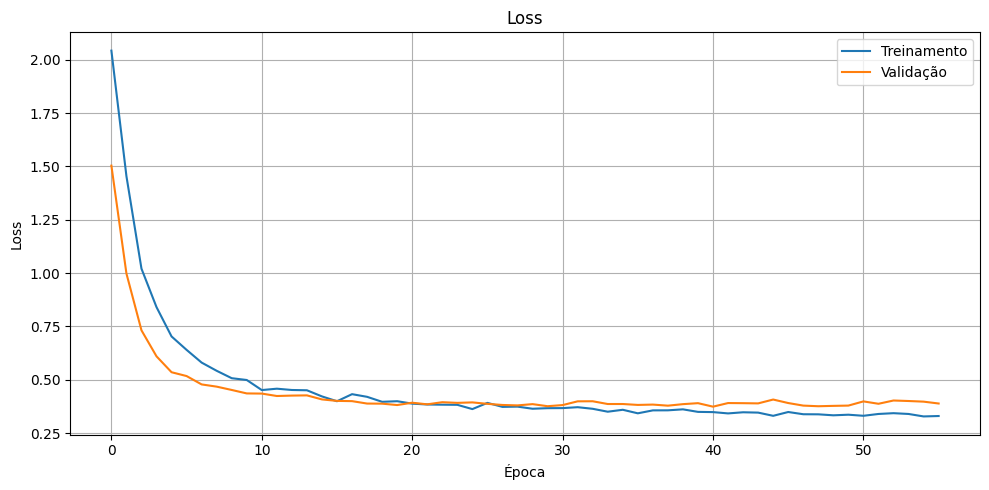

In [15]:
# 16. CURVAS DE TREINAMENTO
plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Treinamento")
plt.plot(history.history["val_accuracy"], label="Validação")
plt.title("Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Treinamento")
plt.plot(history.history["val_loss"], label="Validação")
plt.title("Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
# 17. AVALIAÇÃO
def evaluate_model(y_true, y_pred, names, title):
    print("="*80)
    print(title)
    print("="*80)
    print("Accuracy:          ", f"{accuracy_score(y_true, y_pred):.4f}")
    print("Balanced Accuracy: ", f"{balanced_accuracy_score(y_true, y_pred):.4f}")
    print("Macro-F1:          ", f"{f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print("Weighted-F1:       ", f"{f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print("\nClassification Report:")
    print(classification_report(
        y_true, y_pred, target_names=names, digits=4, zero_division=0
    ))

In [17]:
# 18. VALIDAÇÃO INTERNA
val_prob = model.predict(X_val_scaled, verbose=0)
val_pred = np.argmax(val_prob, axis=1)

evaluate_model(
    y_val_enc, val_pred, class_names,
    "AVALIAÇÃO — VALIDAÇÃO INTERNA"
)

AVALIAÇÃO — VALIDAÇÃO INTERNA
Accuracy:           0.8200
Balanced Accuracy:  0.8200
Macro-F1:           0.7966
Weighted-F1:        0.7966

Classification Report:
                 precision    recall  f1-score   support

             TV     0.9500    0.9500    0.9500        20
   baby_monitor     1.0000    1.0000    1.0000        20
         lights     0.0000    0.0000    0.0000        20
  motion_sensor     1.0000    0.9000    0.9474        20
security_camera     1.0000    1.0000    1.0000        20
 smoke_detector     1.0000    1.0000    1.0000        20
         socket     0.3774    1.0000    0.5479        20
     thermostat     0.9500    0.9500    0.9500        20
          watch     0.9500    0.9500    0.9500        20
   water_sensor     1.0000    0.4500    0.6207        20

       accuracy                         0.8200       200
      macro avg     0.8227    0.8200    0.7966       200
   weighted avg     0.8227    0.8200    0.7966       200



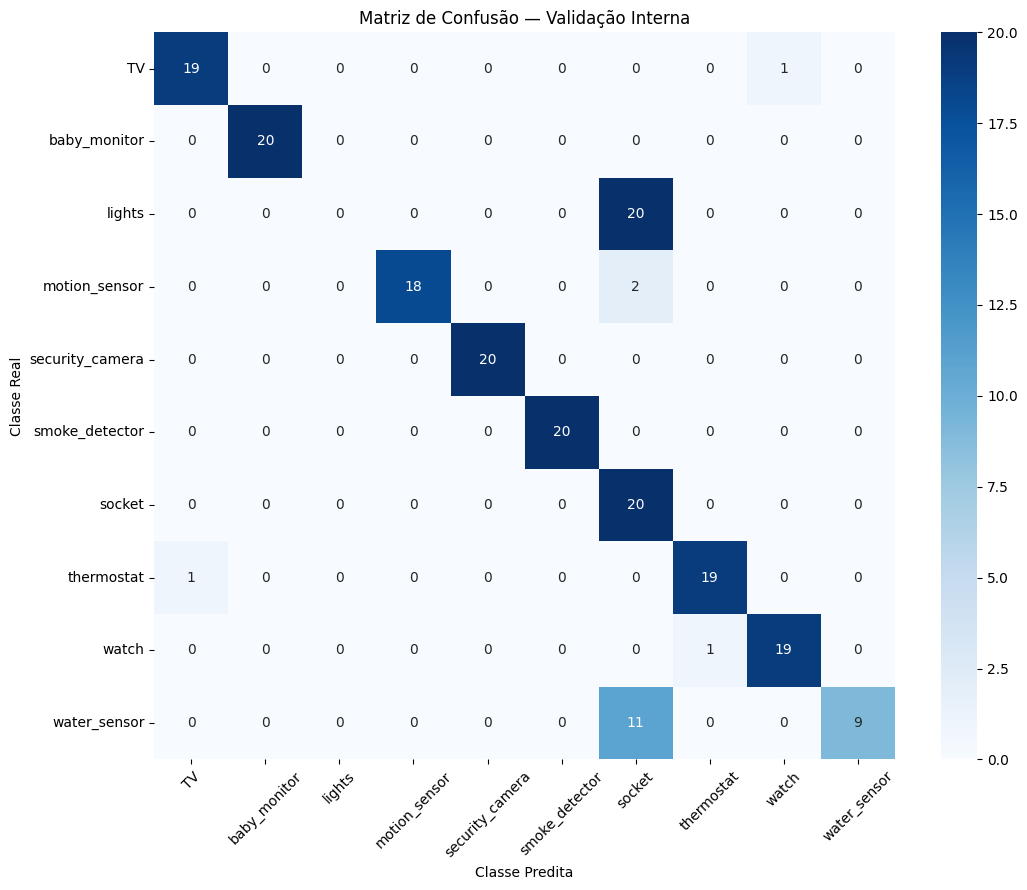

In [18]:
# 19. MATRIZ DE CONFUSÃO — VALIDAÇÃO
cm_val = confusion_matrix(y_val_enc, val_pred, labels=np.arange(NUM_CLASSES))

plt.figure(figsize=(11, 9))
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de Confusão — Validação Interna")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 20. Teste oficial

O modelo treinado será aplicado ao `iot_device_test.csv`, sem qualquer ajuste posterior com base nesses dados.

In [19]:
# 20. TESTE OFICIAL
official_prob = model.predict(X_test_official_scaled, verbose=0)
official_pred = np.argmax(official_prob, axis=1)
official_true = label_encoder.transform(y_test_official)

evaluate_model(
    official_true, official_pred, class_names,
    "AVALIAÇÃO — TESTE OFICIAL"
)

AVALIAÇÃO — TESTE OFICIAL
Accuracy:           0.1911
Balanced Accuracy:  0.1911
Macro-F1:           0.1568
Weighted-F1:        0.1743

Classification Report:
                 precision    recall  f1-score   support

             TV     0.0866    0.1100    0.0969       100
   baby_monitor     0.0000    0.0000    0.0000       100
         lights     0.0000    0.0000    0.0000       100
  motion_sensor     0.2609    0.1200    0.1644       100
security_camera     0.1518    0.1700    0.1604       100
 smoke_detector     0.5109    0.7000    0.5907       100
         socket     0.4222    0.5700    0.4851       100
     thermostat     0.0000    0.0000    0.0000       100
          watch     0.1220    0.0500    0.0709       100
   water_sensor     0.0000    0.0000    0.0000         0

       accuracy                         0.1911       900
      macro avg     0.1554    0.1720    0.1568       900
   weighted avg     0.1727    0.1911    0.1743       900



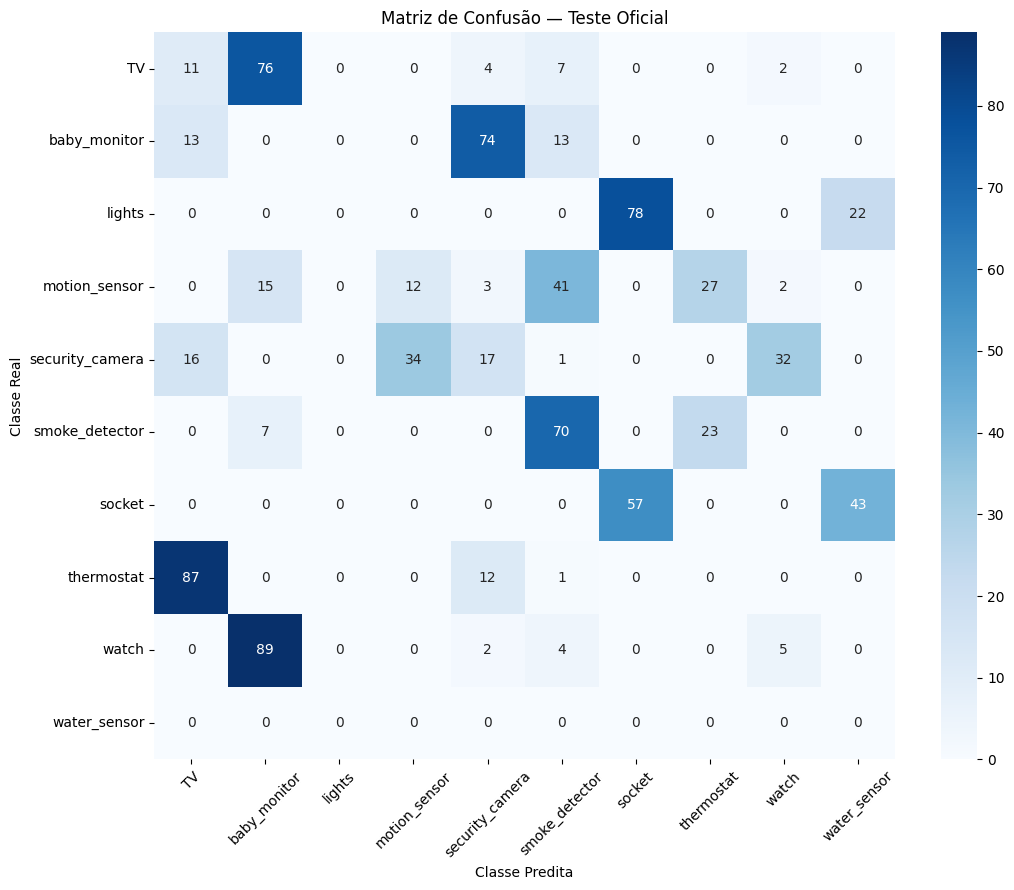

In [20]:
# 21. MATRIZ DE CONFUSÃO — TESTE OFICIAL
cm_test = confusion_matrix(
    official_true, official_pred, labels=np.arange(NUM_CLASSES)
)

plt.figure(figsize=(11, 9))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de Confusão — Teste Oficial")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
# 22. MÉTRICAS POR CLASSE
report = classification_report(
    official_true, official_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

per_class = pd.DataFrame(report).T
per_class = per_class.loc[
    [c for c in class_names if c in per_class.index],
    ["precision", "recall", "f1-score", "support"]
]

display(per_class.sort_values("f1-score"))

,precision,recall,f1-score,support
baby_monitor,0.000000,0.00,0.000000,100.0
lights,0.000000,0.00,0.000000,100.0
thermostat,0.000000,0.00,0.000000,100.0
water_sensor,0.000000,0.00,0.000000,0.0
watch,0.121951,0.05,0.070922,100.0
TV,0.086614,0.11,0.096916,100.0
security_camera,0.151786,0.17,0.160377,100.0
motion_sensor,0.260870,0.12,0.164384,100.0
socket,0.422222,0.57,0.485106,100.0
smoke_detector,0.510949,0.70,0.590717,100.0


## 23. Confiança das previsões

A maior saída do Softmax será usada como medida de confiança operacional. Ela não deve ser interpretada como uma probabilidade calibrada de acerto.

In [22]:
# 23. CONFIANÇA E ERROS
confidence = np.max(official_prob, axis=1)

results = pd.DataFrame({
    "Classe_real": y_test_official.values,
    "Classe_predita": label_encoder.inverse_transform(official_pred),
    "Confianca": confidence
})

results["Confianca_percentual"] = results["Confianca"] * 100
results["Acertou"] = results["Classe_real"] == results["Classe_predita"]

display(results.head(20))

print("Confiança média:", f"{results['Confianca'].mean()*100:.2f}%")
print("Confiança média nos acertos:",
      f"{results.loc[results.Acerto if False else results['Acertou'], 'Confianca'].mean()*100:.2f}%")
print("Confiança média nos erros:",
      f"{results.loc[~results['Acertou'], 'Confianca'].mean()*100:.2f}%")

,Classe_real,Classe_predita,Confianca,Confianca_percentual,Acertou
0,baby_monitor,security_camera,1.000000,99.999992,False
1,baby_monitor,security_camera,1.000000,99.999992,False
2,baby_monitor,security_camera,1.000000,99.999992,False
3,baby_monitor,security_camera,1.000000,99.999992,False
4,baby_monitor,security_camera,1.000000,99.999992,False
5,baby_monitor,security_camera,1.000000,99.999992,False
6,baby_monitor,TV,0.968597,96.859657,False
7,baby_monitor,security_camera,1.000000,99.999992,False
8,baby_monitor,security_camera,1.000000,99.999992,False
9,baby_monitor,security_camera,1.000000,99.999992,False


Confiança média: 87.96%
Confiança média nos acertos: 78.78%
Confiança média nos erros: 90.13%


In [23]:
# 24. ERROS
errors = results[~results["Acertou"]].copy()

print("Quantidade de erros:", len(errors))
print("Taxa de erro:", f"{len(errors)/len(results)*100:.2f}%")

display(errors.sort_values("Confianca", ascending=False).head(30))

error_pairs = (
    errors.groupby(["Classe_real", "Classe_predita"])
    .size()
    .reset_index(name="Quantidade")
    .sort_values("Quantidade", ascending=False)
)

print("\nPrincipais confusões:")
display(error_pairs.head(20))

Quantidade de erros: 728
Taxa de erro: 80.89%


,Classe_real,Classe_predita,Confianca,Confianca_percentual,Acertou
898,watch,baby_monitor,1.0,100.000000,False
897,watch,baby_monitor,1.0,100.000000,False
896,watch,baby_monitor,1.0,100.000000,False
899,watch,baby_monitor,1.0,100.000000,False
306,security_camera,TV,1.0,99.999992,False
300,security_camera,TV,1.0,99.999992,False
296,motion_sensor,smoke_detector,1.0,99.999992,False
294,motion_sensor,thermostat,1.0,99.999992,False
293,motion_sensor,smoke_detector,1.0,99.999992,False
292,motion_sensor,smoke_detector,1.0,99.999992,False



Principais confusões:


,Classe_real,Classe_predita,Quantidade
24,watch,baby_monitor,89
21,thermostat,TV,87
7,lights,socket,78
0,TV,baby_monitor,76
5,baby_monitor,security_camera,74
20,socket,water_sensor,43
11,motion_sensor,smoke_detector,41
15,security_camera,motion_sensor,34
17,security_camera,watch,32
12,motion_sensor,thermostat,27


## 25. Apoio ao inventário

A rede neural identifica a categoria do dispositivo. Uma camada separada compara essa categoria com uma lista de ativos/categorias autorizadas, simulando um mecanismo de apoio ao inventário corporativo.

In [24]:
# 25. INVENTÁRIO SIMULADO
authorized_devices = [
    "lights",
    "motion_sensor",
    "security_camera",
    "thermostat"
]

print("Inventário autorizado:")
for device in authorized_devices:
    print(" -", device)

Inventário autorizado:
 - lights
 - motion_sensor
 - security_camera
 - thermostat


In [25]:
# 26. FUNÇÃO DE IDENTIFICAÇÃO
def identify_asset(sample_index):
    probabilities = official_prob[sample_index]
    predicted_index = np.argmax(probabilities)
    predicted_device = label_encoder.inverse_transform([predicted_index])[0]
    confidence_value = probabilities[predicted_index]
    real_device = y_test_official.iloc[sample_index]

    print("="*70)
    print("IDENTIFICAÇÃO DE ATIVO")
    print("="*70)
    print("Classe real:    ", real_device)
    print("Classe predita: ", predicted_device)
    print(f"Confiança:       {confidence_value*100:.2f}%")

    if predicted_device in authorized_devices:
        print("\nStatus: ✓ Categoria presente no inventário simulado.")
    else:
        print("\nStatus: ⚠ Categoria não presente no inventário simulado.")
        print("Ação sugerida: investigar o ativo.")

    return predicted_device, confidence_value

identify_asset(0)

IDENTIFICAÇÃO DE ATIVO
Classe real:     baby_monitor
Classe predita:  security_camera
Confiança:       100.00%

Status: ✓ Categoria presente no inventário simulado.


('security_camera', np.float32(0.99999994))

In [26]:
# 27. TOP 3 CLASSIFICAÇÕES
sample_index = 0
probabilities = official_prob[sample_index]
top_k = min(3, NUM_CLASSES)

top_indices = np.argsort(probabilities)[::-1][:top_k]

for position, idx in enumerate(top_indices, 1):
    print(f"{position}. {class_names[idx]:25s} {probabilities[idx]*100:.2f}%")

1. security_camera           100.00%
2. TV                        0.00%
3. thermostat                0.00%


## 28. Interpretação de segurança

**Classificação não é autorização.**

A rede neural responde qual categoria de dispositivo é compatível com o padrão de tráfego observado. A organização ainda precisa comparar o ativo identificado com seu inventário e suas regras de autorização.

Portanto, a arquitetura conceitual é:

**tráfego observado → classificação → inventário → investigação/ação**.

In [27]:
# 29. SALVAMENTO DOS ARTEFATOS
OUTPUT_DIR = "/content/iot_project_results_v02"
os.makedirs(OUTPUT_DIR, exist_ok=True)

model.save(os.path.join(OUTPUT_DIR, "iot_device_neural_network_v02.keras"))
joblib.dump(preprocessor, os.path.join(OUTPUT_DIR, "preprocessor_v02.pkl"))
joblib.dump(label_encoder, os.path.join(OUTPUT_DIR, "label_encoder_v02.pkl"))

results.to_csv(
    os.path.join(OUTPUT_DIR, "official_test_predictions_v02.csv"),
    index=False
)

per_class.to_csv(
    os.path.join(OUTPUT_DIR, "per_class_metrics_v02.csv")
)

print("Artefatos salvos em:", OUTPUT_DIR)

Artefatos salvos em: /content/iot_project_results_v02


In [28]:
# 30. RESUMO FINAL
summary = pd.DataFrame({
    "Experimento": [
        "Baseline — validação",
        "Rede Neural — validação",
        "Rede Neural — teste oficial"
    ],
    "Accuracy": [
        accuracy_score(y_val_enc, baseline_pred),
        accuracy_score(y_val_enc, val_pred),
        accuracy_score(official_true, official_pred)
    ],
    "Macro_F1": [
        f1_score(y_val_enc, baseline_pred, average="macro", zero_division=0),
        f1_score(y_val_enc, val_pred, average="macro", zero_division=0),
        f1_score(official_true, official_pred, average="macro", zero_division=0)
    ],
    "Balanced_Accuracy": [
        balanced_accuracy_score(y_val_enc, baseline_pred),
        balanced_accuracy_score(y_val_enc, val_pred),
        balanced_accuracy_score(official_true, official_pred)
    ]
})

display(summary)

print("Features utilizadas:", X_train_scaled.shape[1])
print("Classes:", NUM_CLASSES)
print("Treinamento:", len(X_train))
print("Validação:", len(X_val))
print("Teste oficial:", len(official_true))

,Experimento,Accuracy,Macro_F1,Balanced_Accuracy
0,Baseline — validação,0.100000,0.018182,0.100000
1,Rede Neural — validação,0.820000,0.796600,0.820000
2,Rede Neural — teste oficial,0.191111,0.156842,0.191111


Features utilizadas: 160
Classes: 10
Treinamento: 800
Validação: 200
Teste oficial: 900


# Conclusão

A Versão 02 apresenta uma avaliação metodologicamente mais rigorosa da aplicação de uma Rede Neural Artificial para identificação de dispositivos IoT.

O modelo utiliza características de tráfego de rede para classificar dispositivos em categorias e pode atuar como mecanismo auxiliar de descoberta e inventário de ativos.

Os resultados devem ser analisados conjuntamente por Accuracy, Balanced Accuracy, Macro-F1, métricas por classe, matriz de confusão, confiança e padrões de erro.

Uma limitação relevante é a ausência de `water_sensor` no teste oficial, impossibilitando sua avaliação nesse conjunto.

### Próximos passos
1. seleção de características;
2. comparação com Random Forest e XGBoost;
3. otimização de hiperparâmetros;
4. validação cruzada;
5. explicabilidade;
6. detecção de dispositivos desconhecidos;
7. integração com inventário corporativo.